Everyone should be able to perform and understand: 
		○ Data inspection and problem identification 
		○ Data cleaning 
		○ Exploratory Data Analysis (EDA) 
		○ Train-test split 
		○ Linear Regression model building 
		○ Model prediction/evaluation 
		○ Efforts to achieve the best possible model accuracy 
	


Step1.	Import libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("Libraries loaded!")

Libraries loaded!


step2: Load Raw Data

In [40]:
df = pd.read_csv('housing.csv') 
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [41]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


why we removed - two lines from code 
print("Raw data loaded!")
print("Rows:", len(df), "| Columns:", len(df.columns))

df.info() is used in place of below
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", list(df.columns))
print("\nData types:")
print(df.dtypes)

print(df.isnull().sum()) this code gives same output as below
missing = df.isnull().sum()
print("Missing values in each column:")
print(missing)
print("\nTotal missing:", missing.sum())

In [9]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


Replacing null value with mean value in total bedroom

In [ ]:
mean_values = df['total_bedrooms'].mean()

print("Mean:")
print(mean_values)

Mean:
537.8705525375618


there are two codes for this function with same results= both are same thing.

df['total_bedrooms'] = df['total_bedrooms'].fillna(mean_values)
df.isnull().sum() "or"
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].mean()
)

In [11]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(mean_values)
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Check duplicates

In [13]:
dup_all = df.duplicated().sum()
print("Duplicate rows:", dup_all)
print(df.info())

Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


In [42]:
print(df.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

Ocean proximity 

In [43]:
print(df["ocean_proximity"].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Import model

In [14]:

before = len(df)


after = len(df)
print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Removed:     {before - after}")

Rows before: 20640
Rows after:  20640
Removed:     0


Logic checks (Very important)
what do we check if we already removed null (0) values and duplicates.
and what shoud be the logic
not applying this code for now

In [ ]:
before = len(df)

df = df[df['total rooms'] > 0]
df = df[df['total_bedrooms'] > 0]
df = df[df['High'] >= df['Low']]
df = df[df['Volume'] > 0]

after = len(df)
print(f"Bad rows removed: {before - after}")
print(f"Clean rows left:  {after}")

Step9: Create Helpful new columns
New columns can help analysis later
when visually checked, There is high variability in the data.
I don't see any new columns to be added 

Step10: Final Cleaning Check
After cleaning, always verify again.
not using below lanes
print("Negative Close prices:", (df['Close'] < 0).sum())
print("High < Low rows:", (df['High'] < df['Low']).sum())
I can not make any inferences from the basic stats.

In [18]:
print("=== CLEAN DATA REPORT ===")
print("Rows:", len(df))
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

print("\nBasic stats:")
df[['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']].describe()

=== CLEAN DATA REPORT ===
Rows: 20640
Missing values: 0
Duplicates: 0

Basic stats:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.266592,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,438.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Quick visual check
From visual inspection using excel, data semms to have some outliers that may depend on location of house (or not)
For now I will go ahead with the routine method.

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df['housing_median_age'], df['Close'], color='blue')
plt.title('Tesla Closing Price (After Cleaning)')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.tight_layout()
plt.show()

How can we check - values in one column
I used generate feature to create the code


In [19]:
# Check unique values in a column
print("Unique values in 'ocean_proximity':")
print(df['ocean_proximity'].unique())
print(f"\nCount: {df['ocean_proximity'].nunique()}")

# Check value counts
print("\nValue counts:")
print(df['ocean_proximity'].value_counts())

Unique values in 'ocean_proximity':
<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

Count: 5

Value counts:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [20]:
X = df[['housing_median_age',
        'total_rooms',
        'total_bedrooms',
        'population',
        'households',
        'median_income']]

y = df['median_house_value']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 6)
y shape: (20640,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 16512
Testing rows: 4128


In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [24]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [25]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")

Intercept: -47897.58543802859

Coefficients:
housing_median_age: 1897.00
total_rooms: -20.00
total_bedrooms: 101.94
population: -35.65
households: 127.03
median_income: 47958.91


In [26]:
y_pred = model.predict(X_test)

In [27]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [28]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² score:", r2)

R² score: 0.5448767095949155


With this R2 value, not a good for Linear regression model.

In [29]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

results.head(10)

,Actual Price,Predicted Price
0,47700.0,100859.767098
1,45800.0,144764.551797
2,500001.0,271494.985143
3,218600.0,255417.000906
4,278000.0,219523.289988
5,158700.0,188779.390975
6,198200.0,295727.352779
7,157500.0,227450.083108
8,340000.0,235802.133982
9,446600.0,444196.155104


In [30]:
results['Error'] = results['Actual Price'] - results['Predicted Price']

results.head(10)

,Actual Price,Predicted Price,Error
0,47700.0,100859.767098,-53159.767098
1,45800.0,144764.551797,-98964.551797
2,500001.0,271494.985143,228506.014857
3,218600.0,255417.000906,-36817.000906
4,278000.0,219523.289988,58476.710012
5,158700.0,188779.390975,-30079.390975
6,198200.0,295727.352779,-97527.352779
7,157500.0,227450.083108,-69950.083108
8,340000.0,235802.133982,104197.866018
9,446600.0,444196.155104,2403.844896


In [31]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 56739.98501933227


In [32]:
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("RMSE:", rmse)

RMSE: 77226.78589410303


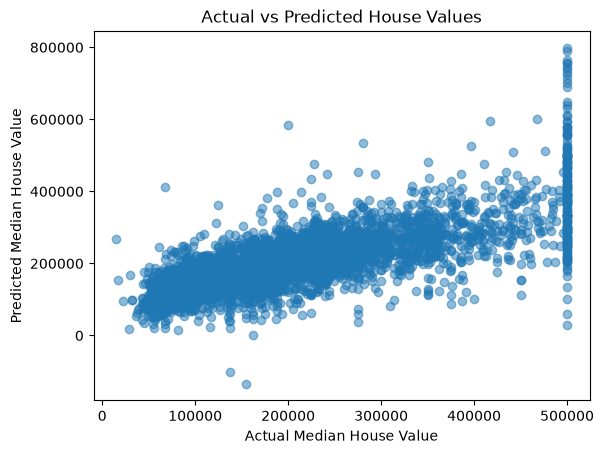

In [33]:

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

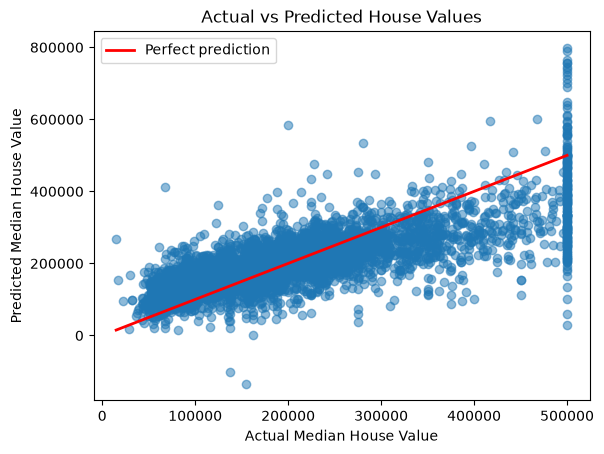

In [34]:
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2,
    label='Perfect prediction'
)

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted House Values")
plt.legend()

plt.show()

In [35]:
X2 = df[[
    'longitude',
    'latitude',
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income'
]]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

r2_model2 = r2_score(y2_test, y2_pred)

print("Model 2 R² score:", r2_model2)

Model 2 R² score: 0.6143987268246028


In [36]:
mae_model2 = mean_absolute_error(y2_test, y2_pred)
rmse_model2 = mean_squared_error(y2_test, y2_pred) ** 0.5

print("Model 2 MAE:", mae_model2)
print("Model 2 RMSE:", rmse_model2)

Model 2 MAE: 51835.734726283554
Model 2 RMSE: 71084.13116794509


In [37]:

comparison = pd.DataFrame({
    'Model': ['Model 1: 6 features', 'Model 2: 8 features'],
    'R²': [r2, r2_model2],
    'MAE': [mae, mae_model2],
    'RMSE': [rmse, rmse_model2]
})

comparison

,Model,R²,MAE,RMSE
0,Model 1: 6 features,0.544877,56739.985019,77226.785894
1,Model 2: 8 features,0.614399,51835.734726,71084.131168


In [38]:
house_number = 0

one_house = X2_test.iloc[[house_number]]

predicted_price = model2.predict(one_house)[0]
actual_price = y2_test.iloc[house_number]

print("Actual house value: $", round(actual_price, 2))
print("Predicted house value: $", round(predicted_price, 2))
print("Difference: $", round(actual_price - predicted_price, 2))

Actual house value: $ 47700.0
Predicted house value: $ 75696.33
Difference: $ -27996.33


In [39]:
house_number = 0

actual_price = y_test.iloc[house_number]

prediction_model1 = model.predict(
    X_test.iloc[[house_number]]
)[0]

prediction_model2 = model2.predict(
    X2_test.iloc[[house_number]]
)[0]

one_house_comparison = pd.DataFrame({
    'Actual Price': [actual_price],
    'Model 1 Prediction': [prediction_model1],
    'Model 2 Prediction': [prediction_model2],
    'Model 1 Error': [actual_price - prediction_model1],
    'Model 2 Error': [actual_price - prediction_model2]
})

one_house_comparison

,Actual Price,Model 1 Prediction,Model 2 Prediction,Model 1 Error,Model 2 Error
0,47700.0,100859.767098,75696.334912,-53159.767098,-27996.334912
